<a href="https://colab.research.google.com/github/Gerardocmdz/VERANO-PDI/blob/main/Lol/AF2_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Datos del equipo

Team Number: #1

Team members:

**Ignacio Alberto Velasco García**

ID: **2177890**

**Dulce Aidé Vega del Angel**

ID: **2068193**

**Odalys Sherlyn Correa Galván**

ID: **2177754**

**Jonathan Sánchez Ramírez**

ID:  **2111769**

**Gael Alejandro Reyes Zaragoza**

ID: **2178099**

Class Schedule:N3

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from google.colab import files

This block imports the main Python libraries used in the activity. Pandas is used to manage the dataset, NumPy supports numerical operations, Matplotlib creates the graphs, MinMaxScaler normalizes the data, and the Colab files module allows the dataset to be uploaded.

In [ ]:
# Upload dataset
uploaded = files.upload()

df = pd.read_csv("diabetes.csv")
df.head()

Saving diabetes.csv to diabetes (2).csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


This block uploads the diabetes.csv file to Google Colab and loads it into a Pandas DataFrame. The head() function is then used to display the first rows and verify that the dataset was loaded correctly.

In [ ]:
# Dataset information
print(df.info())
print("\nNull values:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Null values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age        

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


This block explores the general structure of the dataset. It shows the data types, checks for null values, and generates descriptive statistics such as the mean, median range, standard deviation, minimum, and maximum values.

In [ ]:
# Check invalid zero values
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Invalid zero values:")
for col in zero_columns:
    print(f"{col}: {(df[col] == 0).sum()}")

Invalid zero values:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


This block checks medical variables where a value of zero may represent missing or incorrect data. It counts how many zero values are present in variables such as glucose, blood pressure, skin thickness, insulin, and BMI.

In [ ]:
# Save original glucose data for comparison
glucose_before = df["Glucose"].copy()

# Replace invalid zeros with the median of valid values
for col in zero_columns:
    median = df.loc[df[col] != 0, col].median()
    df[col] = df[col].replace(0, median)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


This block cleans the dataset by replacing invalid zero values with the median of each variable. The median is used because it is less affected by extreme values and provides a reasonable replacement for missing medical measurements.

In [ ]:
# Normalize features using Min-Max Scaling
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

scaler = MinMaxScaler()

df_normalized = df.copy()
df_normalized[features] = scaler.fit_transform(df[features])

df_normalized.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.352941,0.670968,0.489796,0.304348,0.133413,0.314928,0.234415,0.483333,1
1,0.058824,0.264516,0.428571,0.239130,0.133413,0.171779,0.116567,0.166667,0
2,0.470588,0.896774,0.408163,0.239130,0.133413,0.104294,0.253629,0.183333,1
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000,0
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000,1


This block applies Min-Max Scaling to the numerical features of the dataset. The values are transformed to a range between 0 and 1, allowing variables with different measurement scales to be compared more fairly.

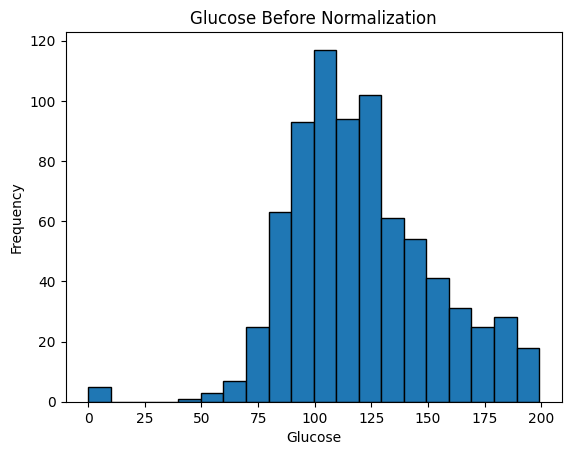

In [ ]:
# Histogram: Glucose before normalization
plt.hist(glucose_before, bins=20, edgecolor="black")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.title("Glucose Before Normalization")
plt.show()

This histogram displays the original distribution of glucose values before normalization. It helps visualize how frequently different glucose levels appear in the dataset.

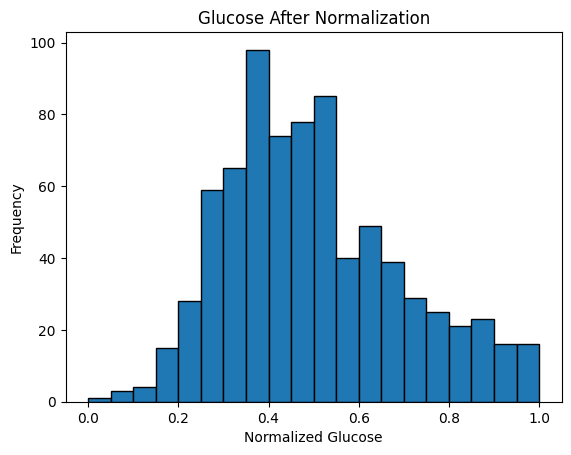

In [ ]:
# Histogram: Glucose after normalization
plt.hist(df_normalized["Glucose"], bins=20, edgecolor="black")
plt.xlabel("Normalized Glucose")
plt.ylabel("Frequency")
plt.title("Glucose After Normalization")
plt.show()

This histogram shows the distribution of glucose values after Min-Max Scaling. The distribution keeps the same general shape, but the values are transformed to a range between 0 and 1.

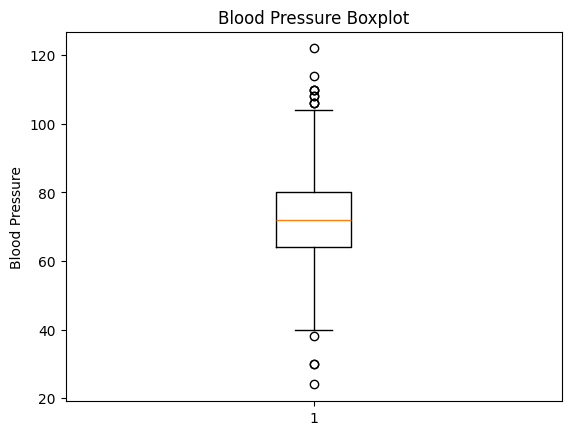

In [ ]:
# Boxplot: Blood Pressure
plt.boxplot(df["BloodPressure"])
plt.ylabel("Blood Pressure")
plt.title("Blood Pressure Boxplot")
plt.show()

This boxplot shows the distribution of blood pressure values and helps identify possible outliers. Values located far from the main group of observations may represent unusual or extreme measurements.

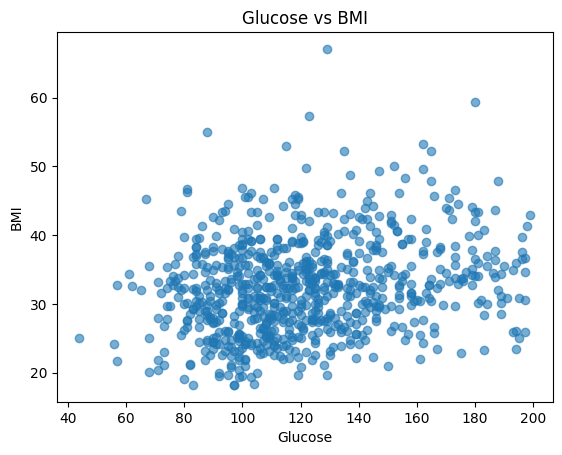

In [ ]:
# Scatter plot: Glucose vs BMI
plt.scatter(df["Glucose"], df["BMI"], alpha=0.6)
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI")
plt.show()

This scatter plot compares glucose levels and BMI for each patient. It is useful for observing possible relationships or patterns between these two biomedical variables.

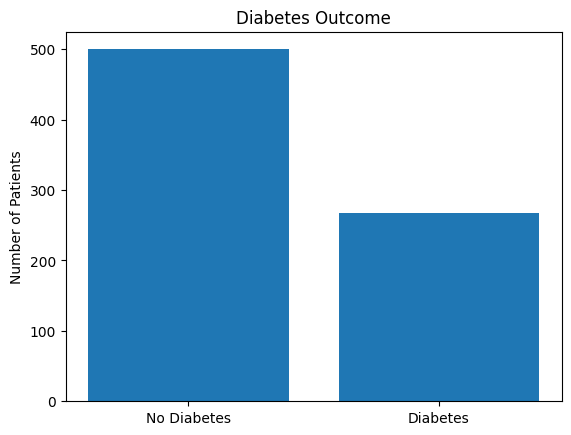

In [ ]:
# Bar chart: Diabetes Outcome
counts = df["Outcome"].value_counts().sort_index()

plt.bar(["No Diabetes", "Diabetes"], counts.values)
plt.ylabel("Number of Patients")
plt.title("Diabetes Outcome")
plt.show()

This bar chart shows the number of patients classified as having diabetes and not having diabetes. It provides a simple way to compare the distribution of the target variable in the dataset.

In [ ]:
# Verify cleaned data
print("Invalid zeros after cleaning:")
for col in zero_columns:
    print(f"{col}: {(df[col] == 0).sum()}")

print("\nNormalized data statistics:")
display(df_normalized.describe())

Invalid zeros after cleaning:
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0

Normalized data statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.226180,0.501008,0.493742,0.240305,0.152250,0.291518,0.168179,0.204015,0.348958
std,0.198210,0.196376,0.123435,0.095557,0.103826,0.140597,0.141473,0.196004,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058824,0.359677,0.408163,0.195652,0.129207,0.190184,0.070773,0.050000,0.000000
50%,0.176471,0.470968,0.489796,0.239130,0.133413,0.288344,0.125747,0.133333,0.000000
75%,0.352941,0.620968,0.571429,0.271739,0.136118,0.376278,0.234095,0.333333,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


This block verifies that the cleaning process was completed correctly. It checks that invalid zero values were replaced and displays descriptive statistics for the normalized dataset to confirm the final data structure.

Preguntas y respuestas